# **Import Libraries**

In [329]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder ,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Load csv file

In [330]:
Path_file= ('/content/College_Student_Predicition.csv')
df=pd.read_csv(Path_file)
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


# **Understanding data**

In [331]:
df.sample(5)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
1699,CLG0038,102,8.85,9.06,7,Yes,8,1,3,No
7364,CLG0011,115,8.62,9.09,4,No,0,7,5,Yes
4721,CLG0009,107,6.18,5.92,7,Yes,9,1,0,No
7830,CLG0041,97,8.01,7.89,6,No,5,6,2,No
2067,CLG0010,97,5.09,4.70,2,No,5,7,2,No


In [332]:
df.shape

(10000, 10)

In [333]:
df.info

<bound method DataFrame.info of      College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0       CLG0030  107             6.61  6.28                     8   
1       CLG0061   97             5.52  5.37                     8   
2       CLG0036  109             5.36  5.83                     9   
3       CLG0055  122             5.47  5.75                     6   
4       CLG0004   96             7.91  7.69                     7   
...         ...  ...              ...   ...                   ...   
9995    CLG0021  119             8.41  8.29                     4   
9996    CLG0098   70             9.25  9.34                     7   
9997    CLG0066   89             6.08  6.25                     3   
9998    CLG0045  107             8.77  8.92                     3   
9999    CLG0060  109             9.41  9.77                     8   

     Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                       No                       8                     8   
1                       No                       7                     8   
2                       No                       3                     1   
3                      Yes                       1                     6   
4                       No                       8                    10   
...                    ...                     ...                   ...   
9995                    No                       1                     8   
9996                    No                       0                     7   
9997                   Yes                       3                     9   
9998                    No                       7                     5   
9999                    No                       3                     5   

      Projects_Completed Placement  
0                      4        No  
1                      0        No  
2                      1        No  
3                      1        No  
4                      2        No  
...                  ...       ...  
9995                   0       Yes  
9996                   2        No  
9997                   5        No  
9998                   1        No  
9999                   5        No  

[10000 rows x 10 columns]>

In [334]:
df=df.drop(['College_ID'],axis=1)

In [335]:
df.isnull().sum()

,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


In [336]:
print(df['Placement'].value_counts())

Placement
No     8341
Yes    1659
Name: count, dtype: int64


In [337]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [338]:
df.duplicated().sum()

np.int64(0)

In [339]:
df.describe

<bound method NDFrame.describe of        IQ  Prev_Sem_Result  CGPA  Academic_Performance Internship_Experience  \
0     107             6.61  6.28                     8                    No   
1      97             5.52  5.37                     8                    No   
2     109             5.36  5.83                     9                    No   
3     122             5.47  5.75                     6                   Yes   
4      96             7.91  7.69                     7                    No   
...   ...              ...   ...                   ...                   ...   
9995  119             8.41  8.29                     4                    No   
9996   70             9.25  9.34                     7                    No   
9997   89             6.08  6.25                     3                   Yes   
9998  107             8.77  8.92                     3                    No   
9999  109             9.41  9.77                     8                    No   

      Extra_Curricular_Score  Communication_Skills  Projects_Completed  \
0                          8                     8                   4   
1                          7                     8                   0   
2                          3                     1                   1   
3                          1                     6                   1   
4                          8                    10                   2   
...                      ...                   ...                 ...   
9995                       1                     8                   0   
9996                       0                     7                   2   
9997                       3                     9                   5   
9998                       7                     5                   1   
9999                       3                     5                   5   

     Placement  
0           No  
1           No  
2           No  
3           No  
4           No  
...        ...  
9995       Yes  
9996        No  
9997        No  
9998        No  
9999        No  

[10000 rows x 9 columns]>

# **EDA Analysis data**

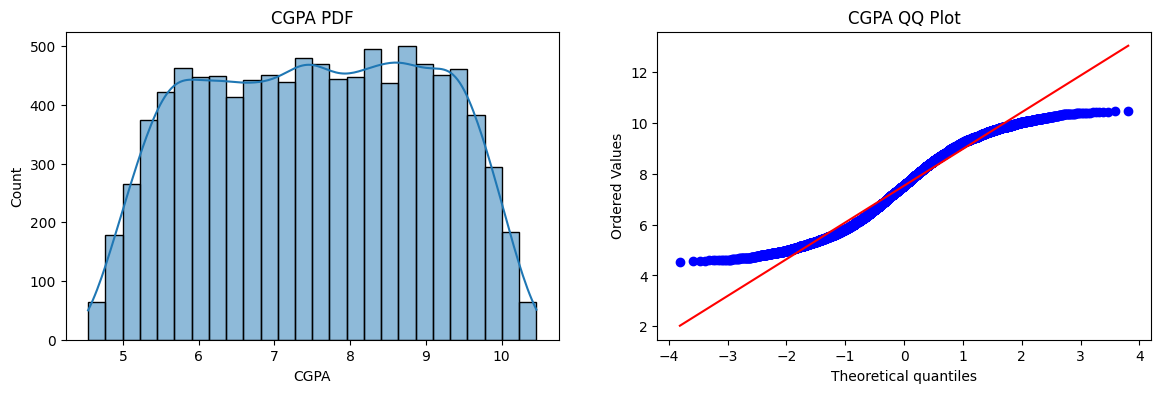

In [340]:

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['CGPA'], kde=True)
plt.title('CGPA PDF')

plt.subplot(122)
stats.probplot(df['CGPA'], dist="norm", plot=plt)
plt.title('CGPA QQ Plot')

plt.show()

/tmp/ipykernel_9201/3376216096.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['IQ'],kde=True)


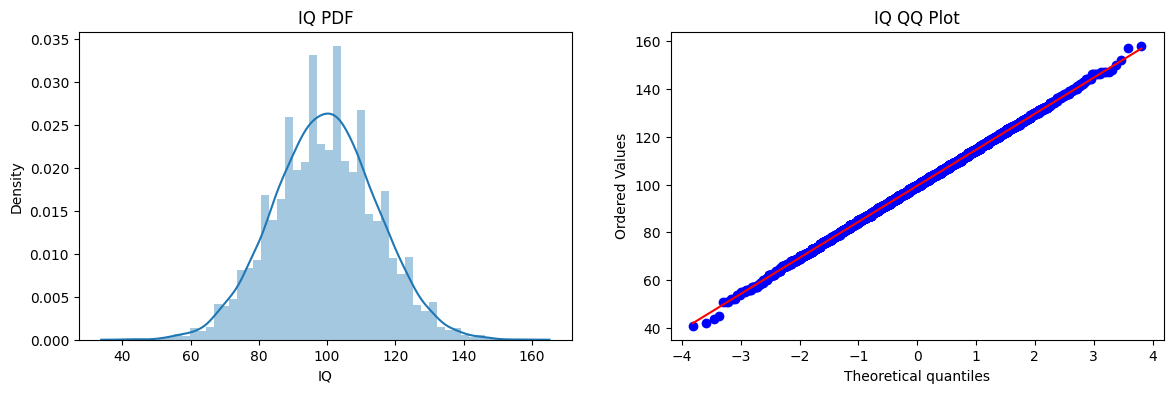

In [341]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['IQ'],kde=True)
plt.title('IQ PDF')

plt.subplot(122)
stats.probplot(df['IQ'], dist="norm", plot=plt)
plt.title('IQ QQ Plot')

plt.show()

<Axes: xlabel='Internship_Experience', ylabel='count'>

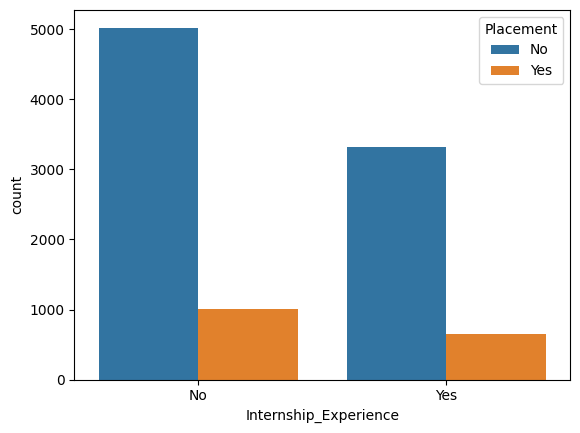

In [342]:
sns.countplot(x='Internship_Experience', hue='Placement', data=df)

<Axes: ylabel='count'>

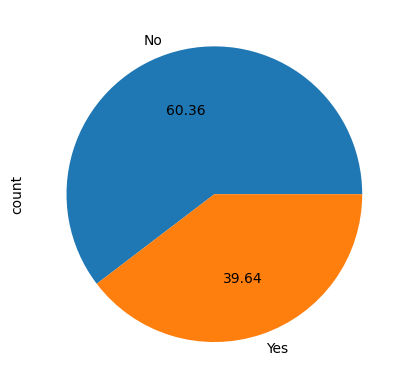

In [343]:
df['Internship_Experience'].value_counts().plot(kind = 'pie',autopct= '%.2f')

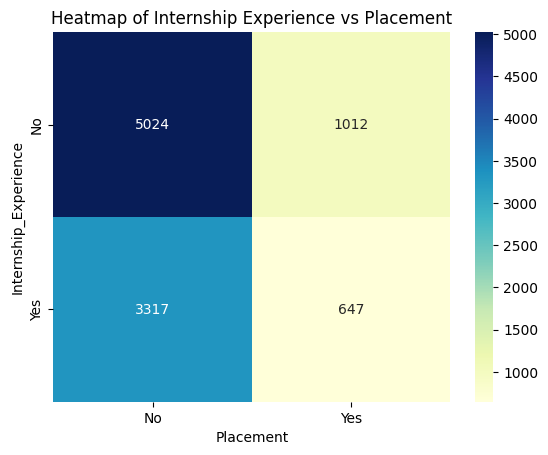

In [344]:
ct = pd.crosstab(df['Internship_Experience'], df['Placement'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Internship Experience vs Placement')
plt.show()

<Axes: xlabel='CGPA', ylabel='IQ'>

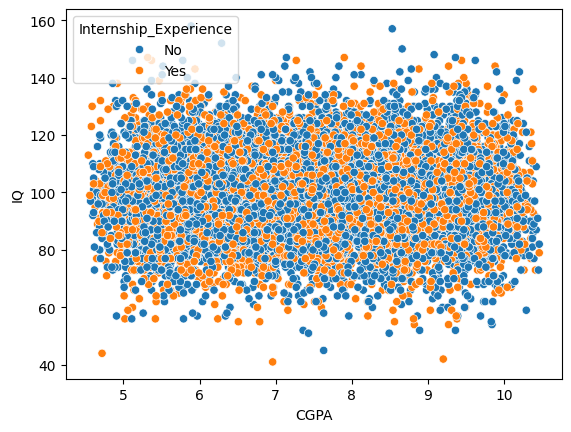

In [345]:
sns.scatterplot(x="CGPA",y="IQ",hue="Internship_Experience",data= df )

<Axes: >

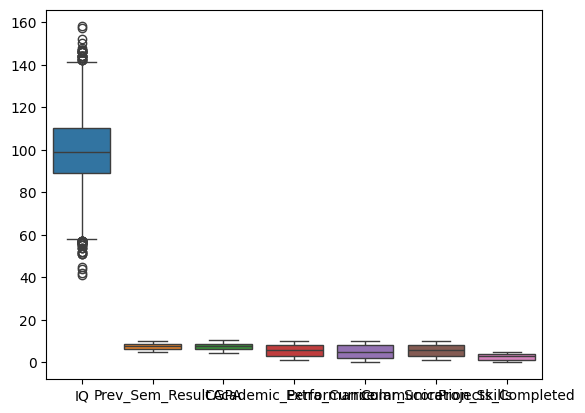

In [346]:
sns.boxplot(df)

<Axes: ylabel='IQ'>

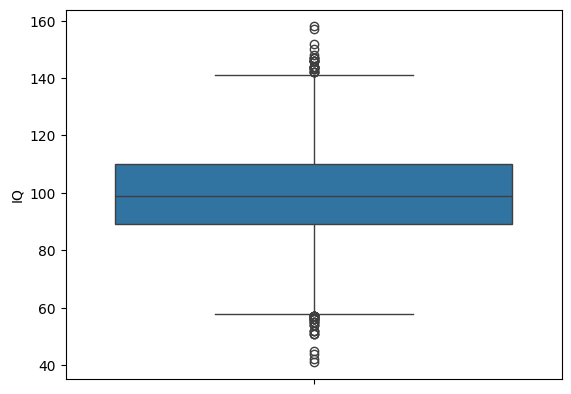

In [347]:
sns.boxplot(df['IQ'])

# **train_test_split**

In [348]:
X = df_new.drop('Placement', axis=1)
y = df_new['Placement']

In [349]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [350]:
X_train

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
6065,96,8.91,8.78,1,No,2,9,2
13036,87,9.49,9.80,3,No,7,10,5
3455,105,9.14,9.44,9,No,1,2,1
6499,95,5.79,5.77,5,No,5,4,5
1680,109,5.35,5.52,9,No,0,5,4
...,...,...,...,...,...,...,...,...
8706,96,7.15,7.06,4,No,5,6,1
14184,124,8.25,8.41,9,Yes,3,8,2
13291,114,5.37,5.42,5,No,0,9,3
13644,95,6.02,6.19,7,No,3,7,5


## **Remove outliers using winsorization**

In [351]:
upper_limit = X_train['IQ'].quantile(0.99)
upper_limit

np.float64(137.0)

In [352]:
lower_limit = X_train['IQ'].quantile(0.01)
lower_limit

np.float64(67.0)

In [353]:
X_train_new = X_train[(X_train['IQ'] <= 134) & (X_train['IQ'] >= 65)]

In [354]:
# Capping --> Winsorization
X_train_new['IQ'] = np.where(X_train_new['IQ'] >= upper_limit,
        upper_limit,
        np.where(X_train_new['IQ'] <= lower_limit,
        lower_limit,
        X_train_new['IQ']))

/tmp/ipykernel_9201/2529804320.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_new['IQ'] = np.where(X_train_new['IQ'] >= upper_limit,


In [355]:
X_train_new.shape

(13043, 8)

<Axes: ylabel='IQ'>

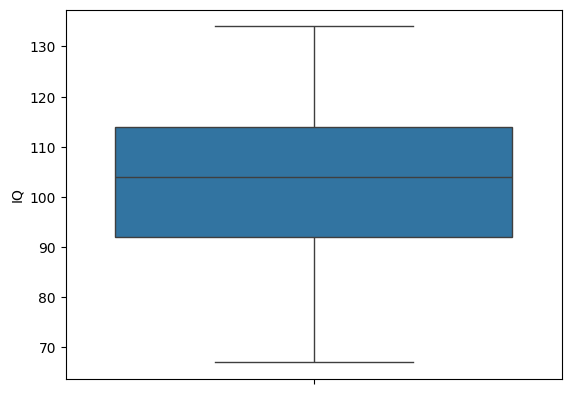

In [356]:
sns.boxplot(X_train_new['IQ'])

# **Column tranformer use (MinMaxScaler ,oneHotEncode)**

In [357]:
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), ['CGPA', 'IQ','Academic_Performance','Prev_Sem_Result', 'Extra_Curricular_Score', 'Communication_Skills']),
    ('cat', OneHotEncoder(sparse_output=False, drop='first'), ['Internship_Experience'])
])

# **using pipeline**

In [358]:
# RandomForestClassifier
pipeline_rf = Pipeline([
    ('prepro', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# LogisticRegression
pipeline_lr = Pipeline([
    ('prepro', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])
# DecisionTreeClassifier
pipeline_dt = Pipeline([
    ('prepro', preprocessor),
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# **Label Encoder **

In [359]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

pipeline_rf.fit(X_train, y_train_encoded)
pipeline_lr.fit(X_train, y_train_encoded)
pipeline_dt.fit(X_train, y_train_encoded)

Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['CGPA', 'IQ',
                                                   'Academic_Performance',
                                                   'Prev_Sem_Result',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Internship_Experience'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [360]:
rf_acc = pipeline_rf.score(X_test, y_test_encoded)
lr_acc = pipeline_lr.score(X_test, y_test_encoded)
dt_acc = pipeline_dt.score(X_test, y_test_encoded)

# **Accuracy and vali_score **

In [361]:
print(f"Random Forest Accuracy:     {rf_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Decision Tree Accuracy:       {dt_acc:.4f}")

Random Forest Accuracy:     0.9709
Logistic Regression Accuracy: 0.8355
Decision Tree Accuracy:       0.9787


# **Classification report**

In [362]:
from sklearn.metrics import classification_report

# Use your actual test data and model predictions from the fitted Random Forest pipeline
y_pred = pipeline_rf.predict(X_test)

# Generate the report using your real encoded test labels
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

          No       1.00      0.94      0.97      1669
         Yes       0.95      1.00      0.97      1668

    accuracy                           0.97      3337
   macro avg       0.97      0.97      0.97      3337
weighted avg       0.97      0.97      0.97      3337



In [363]:
# Encode the full target variable to match the 10,000 samples in X
y_encoded = le.fit_transform(y)

# Run cross-validation on the full dataset
scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='accuracy')

# Encode the full target variable to match the 10,000 samples in X
y_encoded = le.fit_transform(y)

# Run cross-validation on the full dataset
scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='accuracy')

# View results
print(f"Scores for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Scores for each fold: [0.96194186 0.96344022 0.96133094 0.96492806 0.96372902]
Mean Accuracy: 0.9631
Standard Deviation: 0.0013


# **comparing the graph**

/tmp/ipykernel_9201/2219799344.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_new['IQ'])


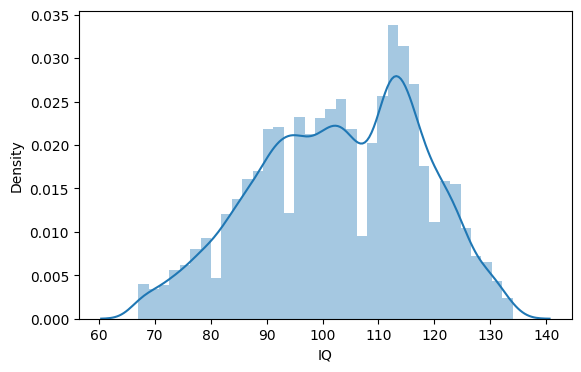

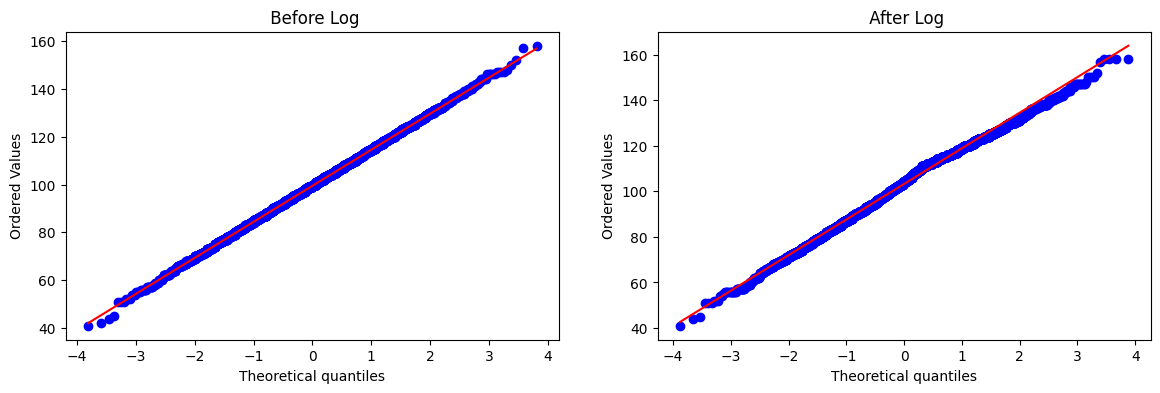

In [364]:

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train_new['IQ'])
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(df['IQ'], dist="norm", plot=plt)
plt.title(' Before Log')

plt.subplot(122)
stats.probplot(X_train['IQ'], dist="norm", plot=plt)
plt.title(' After Log')

plt.show()

# **Import in pickle**

In [365]:
import pickle
pickle.dump(pipeline,open('pipe.pkl','wb'))